Import libaries

In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
import warnings

warnings.filterwarnings("ignore")
sns.set(style='whitegrid')

Import Dataset

In [113]:
df = pd.read_csv('data.csv')
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


EDA

In [114]:
df.shape

(381109, 12)

In [115]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [117]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [118]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


<Axes: xlabel='Response'>

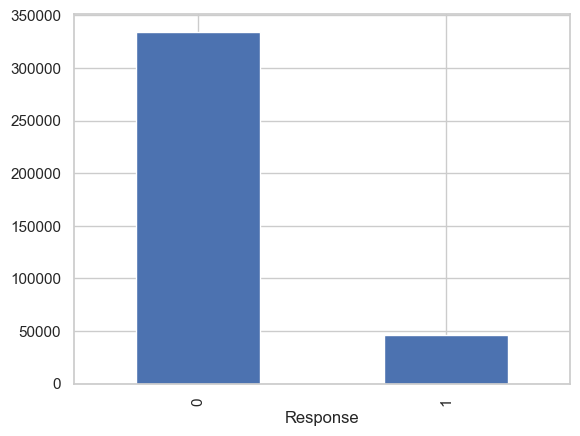

In [119]:
df.Response.value_counts().plot(kind='bar')

<Axes: >

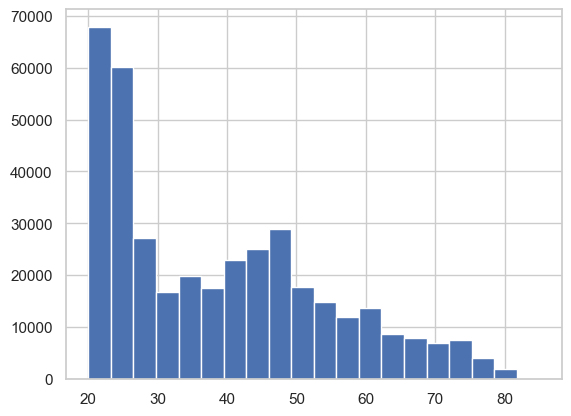

In [120]:
df.Age.hist(bins=20)

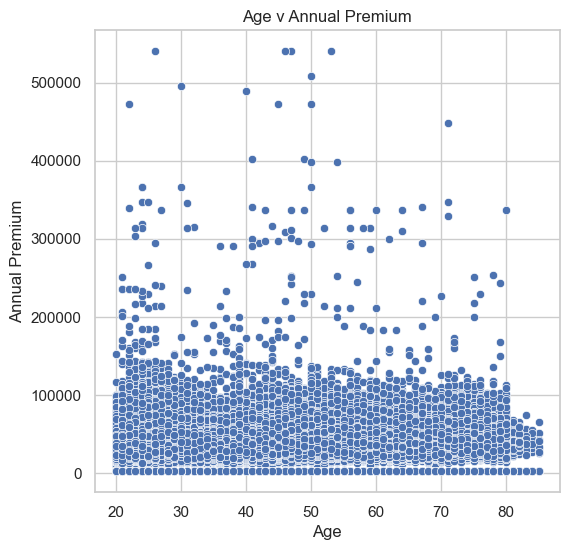

In [121]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='Age',y='Annual_Premium',data=df)
plt.title('Age v Annual Premium')
plt.xlabel("Age")
plt.ylabel("Annual Premium")
plt.show()

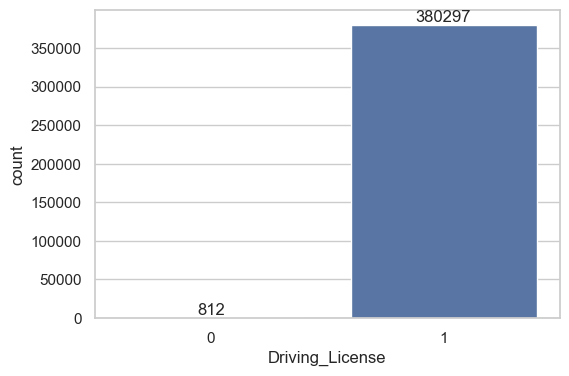

In [122]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Driving_License', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.show()


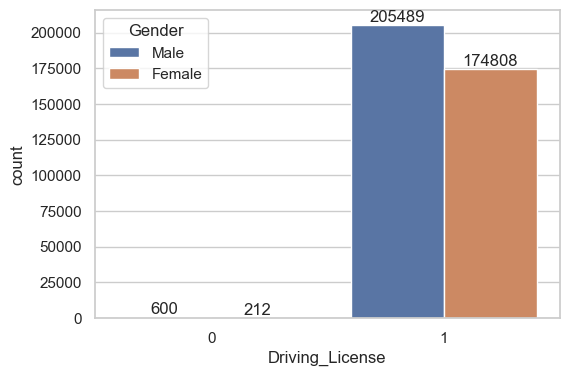

In [123]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Driving_License', data=df, hue='Gender')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

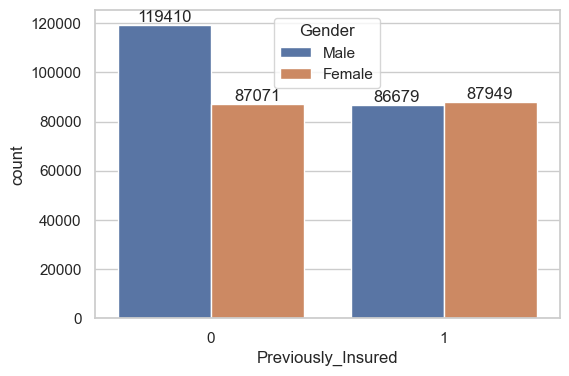

In [124]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Previously_Insured', data=df, hue='Gender')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

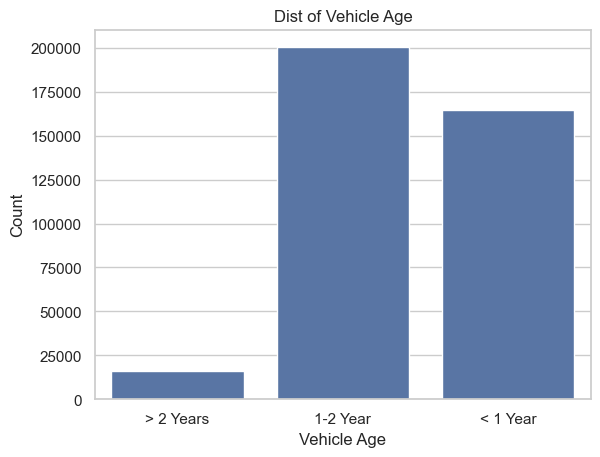

In [125]:
sns.countplot(x='Vehicle_Age',data=df)
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.title('Dist of Vehicle Age')
plt.show()

In [126]:
data =df.groupby(['Vehicle_Age','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
data

,Vehicle_Age,Response,count
0,1-2 Year,0,165510
1,1-2 Year,1,34806
2,< 1 Year,0,157584
3,< 1 Year,1,7202
4,> 2 Years,0,11305
5,> 2 Years,1,4702


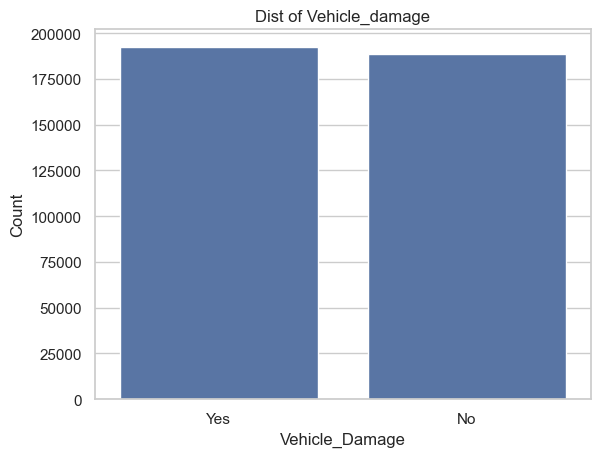

In [127]:
sns.countplot(x='Vehicle_Damage',data=df)
plt.xlabel('Vehicle_Damage')
plt.ylabel('Count')
plt.title('Dist of Vehicle_damage')
plt.show()

<Axes: >

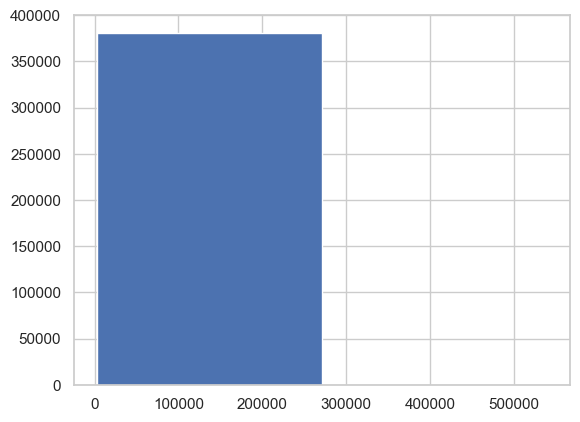

In [128]:
df.Annual_Premium.hist(bins=2)

Data Preprocessing

In [129]:
numerical_features = ['Age','Vintage']
categorical_features = ['Gender','Driving_License','Previously_Insured','Vehicle_Age','Vehicle_Damage','Region_Code']

In [130]:
df.Gender = df.Gender.map({'Female':0,'Male':1}).astype(int)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [131]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int32
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Vehicle_Age >> object
Vehicle_Damage >> object
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64


In [132]:
df = pd.get_dummies(df,drop_first=True)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,1,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,1,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,0,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [133]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int32
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64
Vehicle_Age_< 1 Year >> bool
Vehicle_Age_> 2 Years >> bool
Vehicle_Damage_Yes >> bool


In [134]:
df = df.rename(columns={'Vehicle_Age_< 1 Year':'Vehicle_Age_lt_1_Year','Vehicle_Age_> 2 Years':'Vehicle_Age_gt_2_Years'})

df['Vehicle_Age_lt_1_Year'] = df['Vehicle_Age_lt_1_Year'].astype(int)
df['Vehicle_Age_gt_2_Years'] = df['Vehicle_Age_gt_2_Years'].astype(int)

df['Vehicle_Damage_Yes'] = df['Vehicle_Damage_Yes'].astype(int)


In [135]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")


id >> int64
Gender >> int32
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64
Vehicle_Age_lt_1_Year >> int32
Vehicle_Age_gt_2_Years >> int32
Vehicle_Damage_Yes >> int32


In [136]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,0,1,1
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,0,0,0
2,3,1,47,1,28.0,0,38294.0,26.0,27,1,0,1,1
3,4,1,21,1,11.0,1,28619.0,152.0,203,0,1,0,0
4,5,0,29,1,41.0,1,27496.0,152.0,39,0,1,0,0


In [137]:
# Scaling the data

from sklearn.preprocessing import StandardScaler, MinMaxScaler

sc = StandardScaler()

df[numerical_features] = sc.fit_transform(df[numerical_features])

mm = MinMaxScaler()

df[['Annual_Premium']] = mm.fit_transform(df[['Annual_Premium']])

id = df.id
df = df.drop('id',axis=1)

In [138]:
# Train test split
from sklearn.model_selection import train_test_split

y = df.Response
x = df.drop(['Response'],axis=1)
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=22,stratify=y)

In [139]:
y

0         1
1         0
2         1
3         0
4         0
         ..
381104    0
381105    0
381106    0
381107    0
381108    0
Name: Response, Length: 381109, dtype: int64

In [140]:
x.head(2)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Years,Vehicle_Damage_Yes
0,1,0.333777,1,28.0,0,0.070366,26.0,0.748795,0,1,1
1,1,2.396751,1,3.0,0,0.057496,26.0,0.342443,0,0,0


In [142]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=52)
x_train_sm , y_train_sm = sm.fit_resample(x_train,y_train)



In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

params = {
    'criterion' : ['entrophy','gini'],
    'max_depth' : [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf' : [2,4,6,8],
    'min_samples_split' : [3,5,7,10],
    'n_estimators' : [250,300]
}

rf = RandomForestClassifier()
model = RandomizedSearchCV(rf,param_distributions=params,n_iter=10,cv=5,verbose=1,random_state=52,n_jobs=-1)
model.fit(x_train_sm,y_train_sm)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'criterion': ['entrophy', 'gini'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [3, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,52
,error_score,nan


In [146]:
best_params = model.best_params_

print("Best Hyperparas:")
print(best_params)

Best Hyperparas:
{'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 8, 'criterion': 'gini'}


In [147]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=250,
    min_samples_split=5,
    max_depth=2,
    criterion='gini',
    random_state=52,
    class_weight='balanced'
)

clf.fit(x_train_sm, y_train_sm)

,n_estimators,250
,criterion,'gini'
,max_depth,2
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [148]:
import pickle

filename = 'rf_model.pkl'
pickle.dump(clf,open(filename,'wb'))

In [149]:
# Load model

rf_load = pickle.load(open(filename,'rb'))

Model Evaluation

In [150]:
from sklearn.metrics import classification_report

y_pred = clf.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.67      0.80     83600
           1       0.28      0.92      0.43     11678

    accuracy                           0.70     95278
   macro avg       0.63      0.79      0.61     95278
weighted avg       0.90      0.70      0.75     95278



In [ ]:
# from ydata_profiling import ProfileReport

# dff = pd.read_csv('data.csv')

# prof = ProfileReport(dff,title='Vehicle Insurance Report',explorative=True)

# prof.to_file("insurance_report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:06<00:00,  1.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]